En esta notebook realizamos un análisis exploratorio de los datos, el objetivo es comprender el dataset, los tipos de datos de cada variable, valores faltantes, distribución de las clases, realizar gráficos que nos aporten información, etc. 

In [ ]:
# Importamos librerias a utilizar
from scipy.io import arff
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [47]:
#Cargamos el dataset y lo transformamos en un DataFrame de pandas para poder manipularlo de manera más sencilla.

data, meta = arff.loadarff("/Users/Camila/Desktop/datasets/dataset_31_credit-g.arff")
df = pd.DataFrame(data)

#Decodificamos los strings que provienen del archivo ARFF para que sean legibles y consistentes en el DataFrame.
for column in df.select_dtypes([object]).columns:
    df[column] = df[column].str.decode('utf-8')
    

In [27]:
df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6.0,critical/other existing credit,radio/tv,1169.0,no known savings,>=7,4.0,male single,none,...,real estate,67.0,none,own,2.0,skilled,1.0,yes,yes,good
1,0<=X<200,48.0,existing paid,radio/tv,5951.0,<100,1<=X<4,2.0,female div/dep/mar,none,...,real estate,22.0,none,own,1.0,skilled,1.0,none,yes,bad
2,no checking,12.0,critical/other existing credit,education,2096.0,<100,4<=X<7,2.0,male single,none,...,real estate,49.0,none,own,1.0,unskilled resident,2.0,none,yes,good
3,<0,42.0,existing paid,furniture/equipment,7882.0,<100,4<=X<7,2.0,male single,guarantor,...,life insurance,45.0,none,for free,1.0,skilled,2.0,none,yes,good
4,<0,24.0,delayed previously,new car,4870.0,<100,1<=X<4,3.0,male single,none,...,no known property,53.0,none,for free,2.0,skilled,2.0,none,yes,bad


In [18]:
#Vemos cantidad de filas y columnas del dataset
print(f'El dataset tiene{df.shape[0]} filas y {df.shape[1]} columnas\n')

print('Vemos los tipos de datos de cada columna, y cuantos valores únicos poseen:')
for col in df:
    print(f"{col}: {df[col].nunique()} |  {df[col].dtypes}")



El dataset tiene1000 filas y 21 columnas

Vemos los tipos de datos de cada columna, y cuantos valores únicos poseen:
checking_status: 4 |  object
duration: 33 |  float64
credit_history: 5 |  object
purpose: 10 |  object
credit_amount: 921 |  float64
savings_status: 5 |  object
employment: 5 |  object
installment_commitment: 4 |  float64
personal_status: 4 |  object
other_parties: 3 |  object
residence_since: 4 |  float64
property_magnitude: 4 |  object
age: 53 |  float64
other_payment_plans: 3 |  object
housing: 3 |  object
existing_credits: 4 |  float64
job: 4 |  object
num_dependents: 2 |  float64
own_telephone: 2 |  object
foreign_worker: 2 |  object
class: 2 |  object


In [15]:
#Analizamos si la variable objetivo está balanceada o desbalanceada
df['class'].value_counts()

class
good    700
bad     300
Name: count, dtype: int64

In [42]:
#Analizamos si hay valores faltantes
df.isnull().sum()

checking_status           0
duration                  0
credit_history            0
purpose                   0
credit_amount             0
savings_status            0
employment                0
installment_commitment    0
personal_status           0
other_parties             0
residence_since           0
property_magnitude        0
age                       0
other_payment_plans       0
housing                   0
existing_credits          0
job                       0
num_dependents            0
own_telephone             0
foreign_worker            0
class                     0
dtype: int64

In [48]:
columnas_numericas = df.select_dtypes(include="number").columns
columnas_categoricas = df.select_dtypes(include='object').columns

In [9]:
columnas_numericas

Index(['duration', 'credit_amount', 'installment_commitment',
       'residence_since', 'age', 'existing_credits', 'num_dependents'],
      dtype='object')

Hay ciertas variables que particularmente creo que podrían tener un mayor impacto en definir si un crédito será bueno o malo, a continuación realizo un mínimo análisis sobre dichas variables

In [37]:
print(df.groupby('credit_history')['credit_amount'].mean())
print(df.groupby('job')['credit_amount'].mean())


credit_history
all paid                          3344.877551
critical/other existing credit    3088.037543
delayed previously                4302.602273
existing paid                     3040.958491
no credits/all paid               5305.675000
Name: credit_amount, dtype: float64
job
high qualif/self emp/mgmt    5435.493243
skilled                      3070.965079
unemp/unskilled non res      2745.136364
unskilled resident           2358.520000
Name: credit_amount, dtype: float64


- Vemos que las personas con historial crediticio critico suelen tener montos de crédito más bajo, lo cual puede indicar que el mismo es un factor importante a la hora de definir montos de créditos otorgados. También podemos observar que las personas que no tienen historial crediticio (o si lo tenian, ya fue pagado), tienden a tener montos de crédito más altos, lo cual podría indicar que la falta de historial crediticio no es necesariamente un factor negativo a la hora de otorgar créditos

- Otra cosa interesante que podemos notar es que las personas que estan desempleadas o poseen un tipo de trabajo del tipo uneskilled, tienden a tener montos de crédito más altos que las personas que poseen directamente un tipo de trabajo unskilled. Vamos a ver cuales de ellos generan más riesgo de impago.


In [39]:
# Crea la tabla cruzada: filas = tipos de trabajo, columnas = clases
tabla_cruces = pd.crosstab(df['job'], df['class'], margins=True, margins_name="Total")

print(tabla_cruces)

print('-----------------')

# Muestra el porcentaje de cada clase dentro de cada tipo de trabajo
tabla_porcentajes = pd.crosstab(df['job'], df['class'], normalize='index') * 100

print(tabla_porcentajes.round(2))

class                      bad  good  Total
job                                        
high qualif/self emp/mgmt   51    97    148
skilled                    186   444    630
unemp/unskilled non res      7    15     22
unskilled resident          56   144    200
Total                      300   700   1000
-----------------
class                        bad   good
job                                    
high qualif/self emp/mgmt  34.46  65.54
skilled                    29.52  70.48
unemp/unskilled non res    31.82  68.18
unskilled resident         28.00  72.00


Podemos notar que el otorgamiento de créditos a personas desempleadas es sumamente menor al de personas con tipo de trabajo "unskilled". Y además, si bien la diferencia no es importante, las personas desempleadas suelen generar mayor cantidad de malos créditos. 

### CREACIÓN DE GRÁFICOS
Vamos a ver distintos gráficos, a intentar identificar patrones/relaciones, y en base a ello tratar de obtener información.

/var/folders/77/8wfmp3hx6_v0440sd1_2lfnr0000gp/T/ipykernel_48706/2091603085.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x = 'class', y = col, palette= 'Pastel1' )
/var/folders/77/8wfmp3hx6_v0440sd1_2lfnr0000gp/T/ipykernel_48706/2091603085.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x = 'class', y = col, palette= 'Pastel1' )
/var/folders/77/8wfmp3hx6_v0440sd1_2lfnr0000gp/T/ipykernel_48706/2091603085.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x = 'class', y = col, palette= 'Pastel1' )


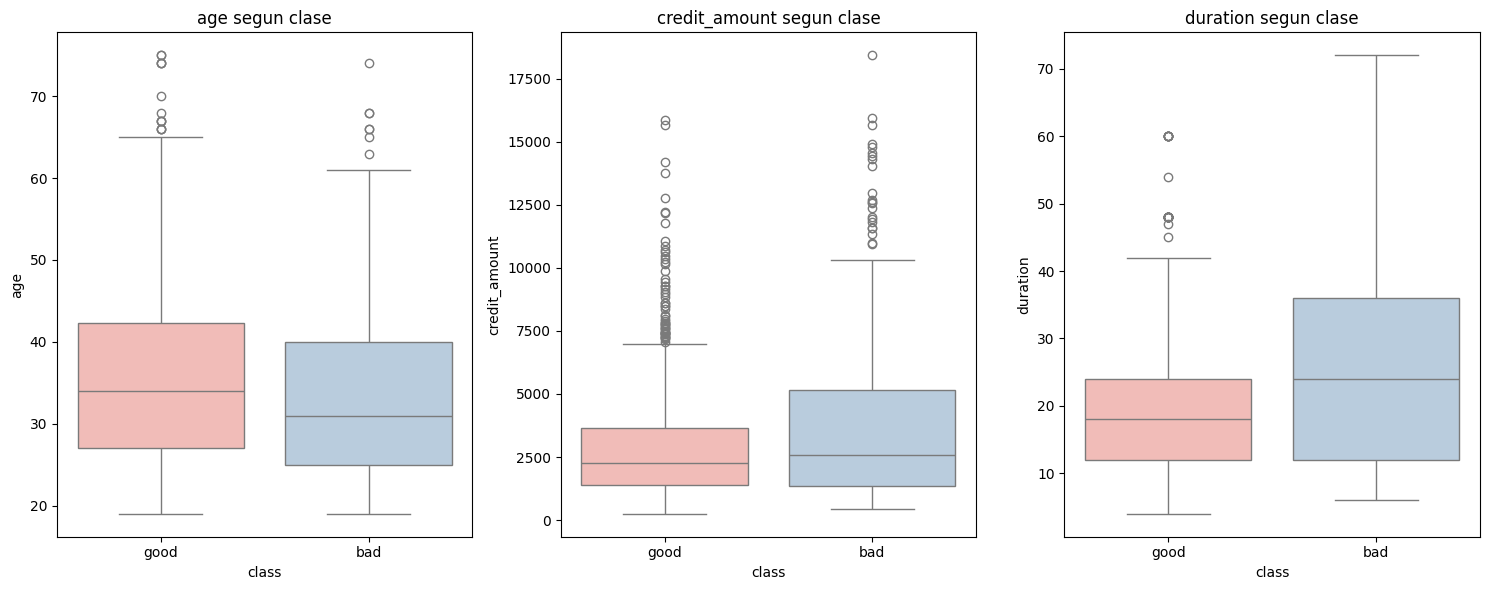

In [67]:
plt.figure(figsize=(15,6))
for i, col in enumerate(['age','credit_amount','duration']):
    plt.subplot(1,3, i+1)
    sns.boxplot(data = df, x = 'class', y = col, palette= 'Pastel1' )
    plt.title(f'{col} segun clase')
    
plt.tight_layout()
plt.show()

Por lo que podemos observar en estos Box Plots, en donde vemos la distribución de los datos y valores outliers, es que los créditos malos poseen valores valores más altos, ya que se observan más valores extremos, a comparación de la clase buena, aunque la diferencia no es demasiada.
Lo mismo ocurre con la relación, en donde los malos créditos suelen tomar más tiempo, esto puede relacionarse con los montos altos vistos en el segundo plot. 

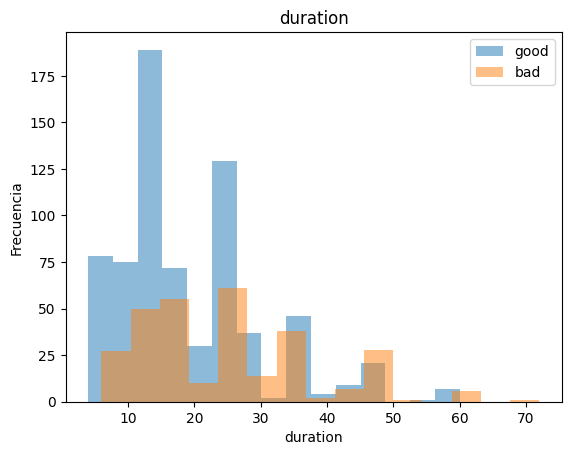

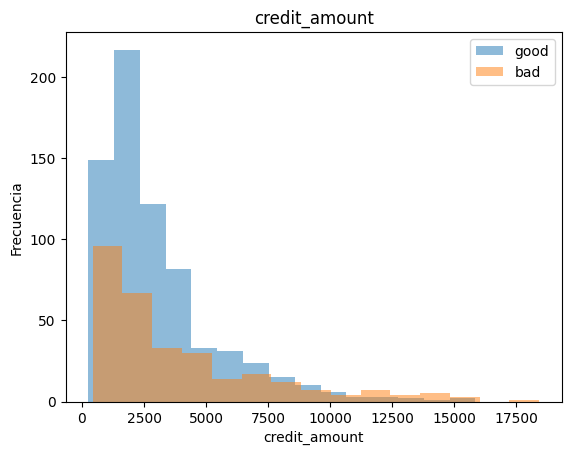

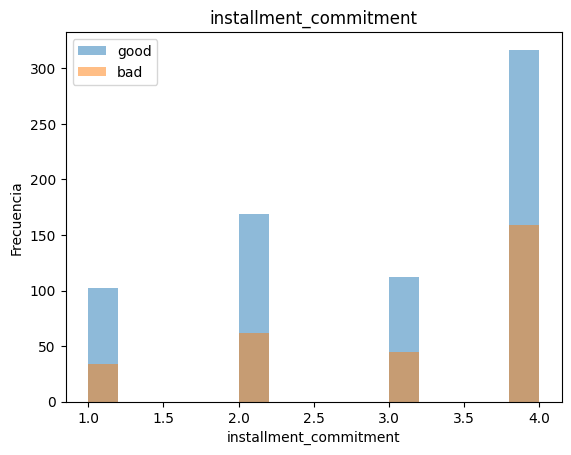

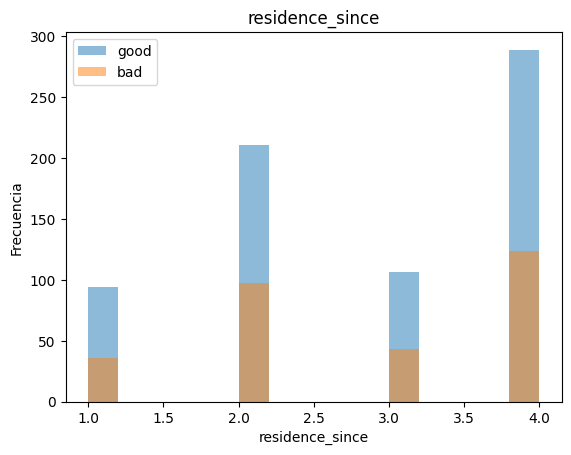

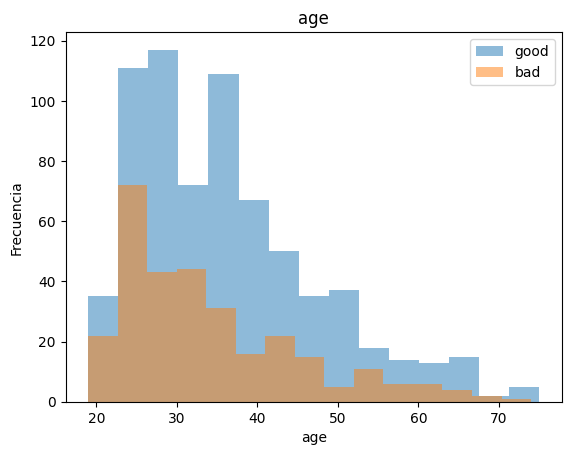

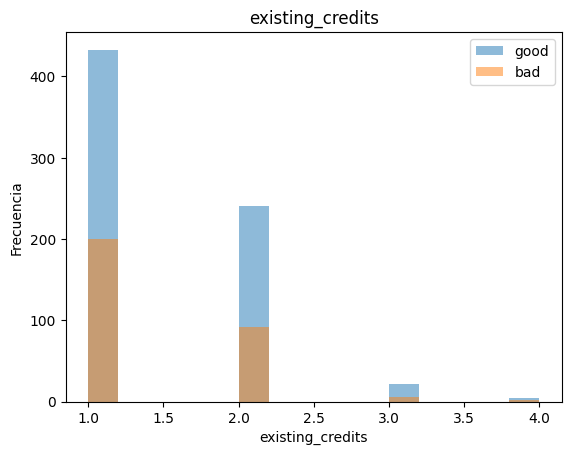

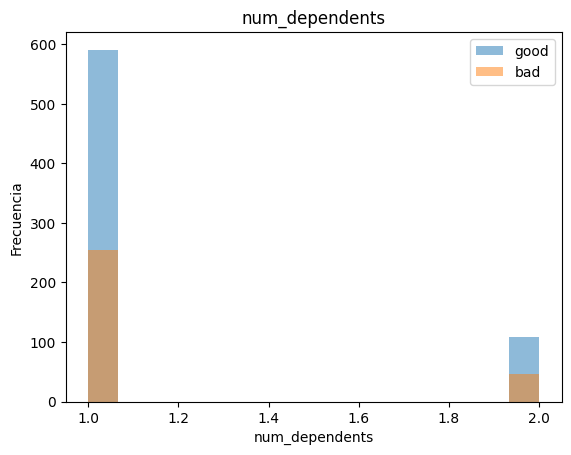

In [ ]:
for col in columnas_numericas:
    plt.figure()
    for clase in df['class'].unique():
        plt.hist(
            df[df['class'] == clase] [col],
            alpha = 0.5,
            label = clase,
            bins=15  )
    
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.legend()
    plt.show()

Realizo una matriz de correlación de las variables numéricas para poder ver si hay variables altamente correlacionadas. Podremos ver que hay dos variables con una fuerte correlación, y son 'credit amount' y 'duration', lo cual tiene sentido, pues generalmente, a mayor es el monto del crédito, más largo suele ser el plazo de pago. 

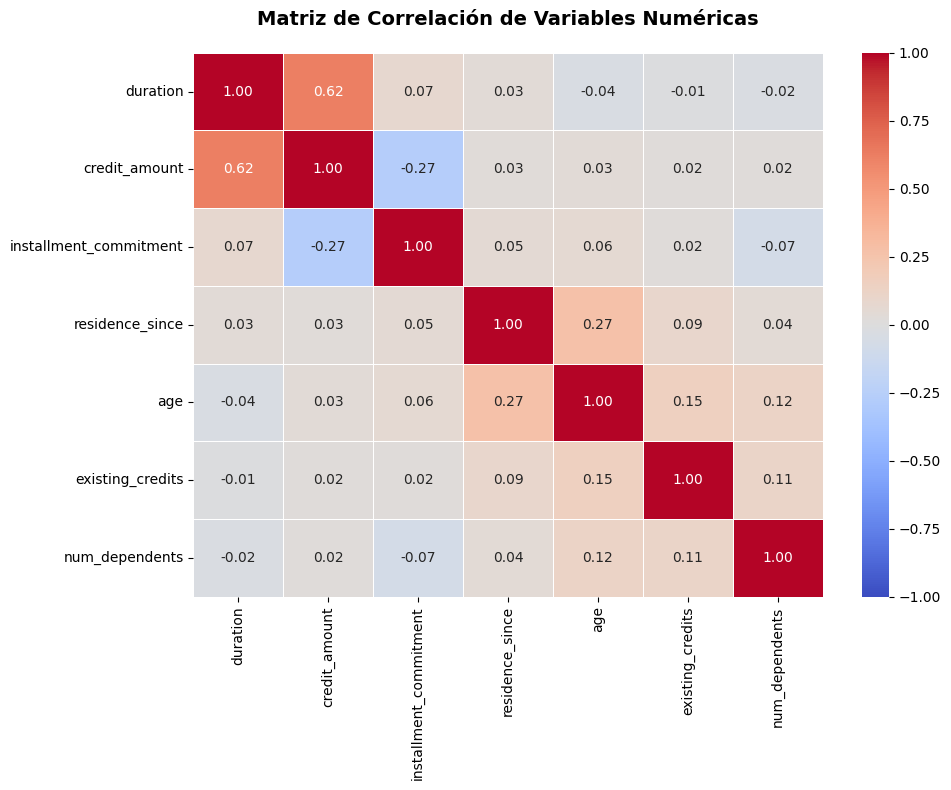

In [ ]:
matriz_corr = df[columnas_numericas].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    matriz_corr, 
    annot=True,          
    cmap='coolwarm',     
    fmt=".2f",           
    linewidths=0.5,      
    vmin=-1, vmax=1     
)
plt.title('Matriz de Correlación de Variables Numéricas', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


De estos gráficos no podemos obtener información muy relevante o decisoria. Quizás podríamos inferir, a partir del gráfico de a la variable "credit amount", que aquellos préstamos de los montos más elevados, son créditos malos.

A continuación realizaremos gráficos de barras apiladas en porcentajes, cuyo objetivo será analizar la relación entre las variables predictoras y la variable objetivo (clase). Esto nos permitirá observar la distribución porcentual de créditos buenos y malos para cada categoría específica. De este modo, podremos identificar qué valores se asocian con un mayor riesgo crediticio y detectar señales tempranas de alerta. 


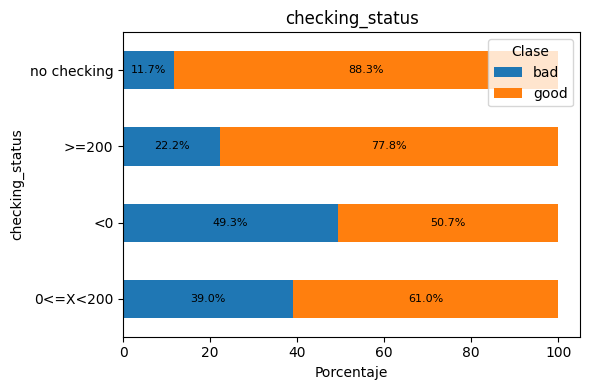

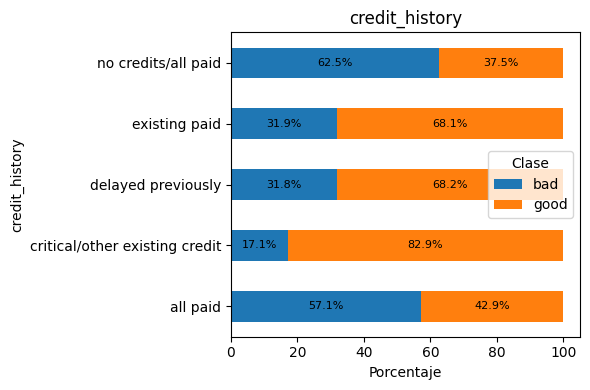

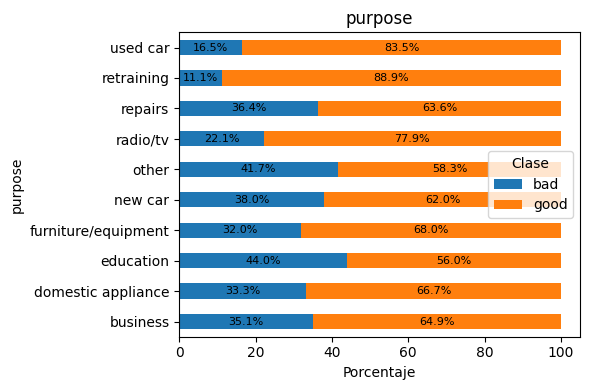

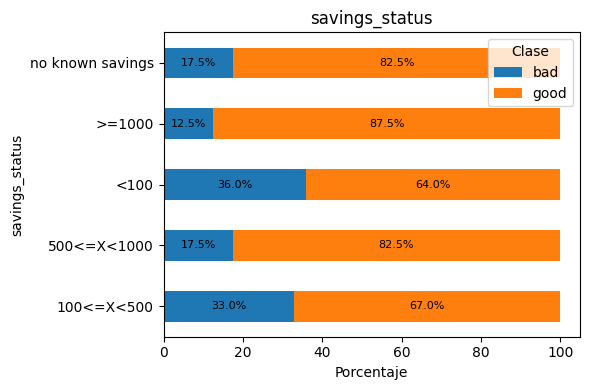

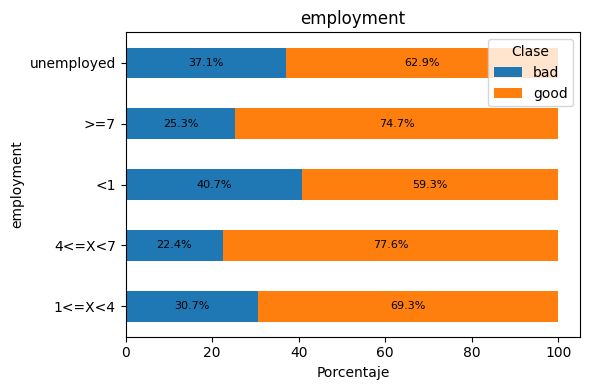

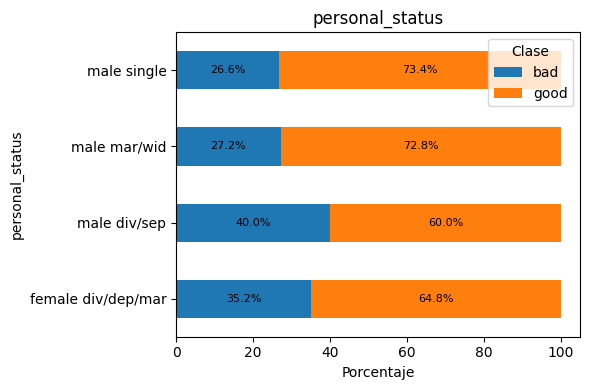

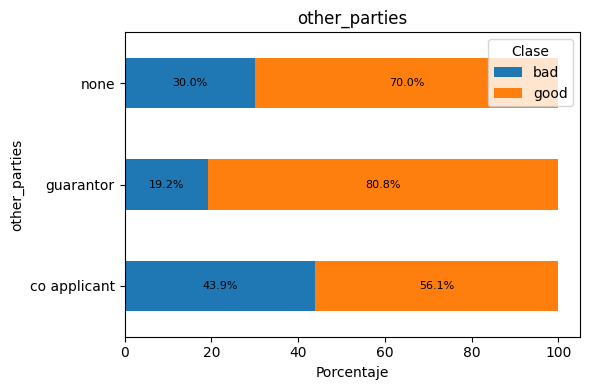

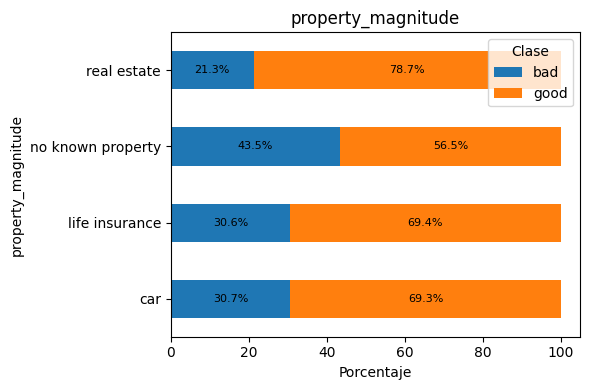

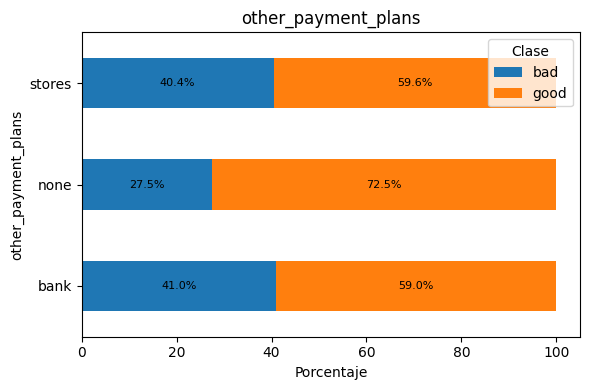

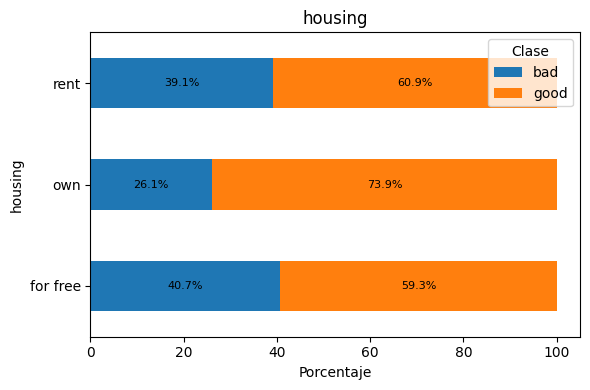

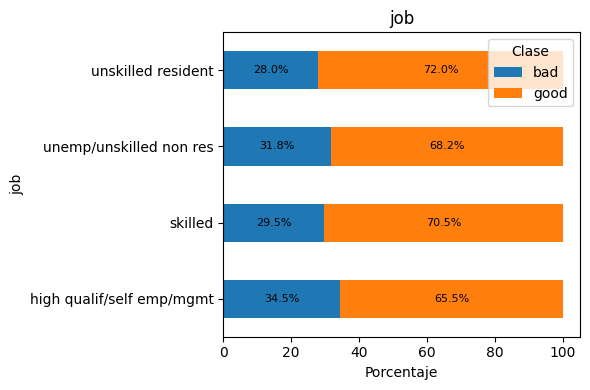

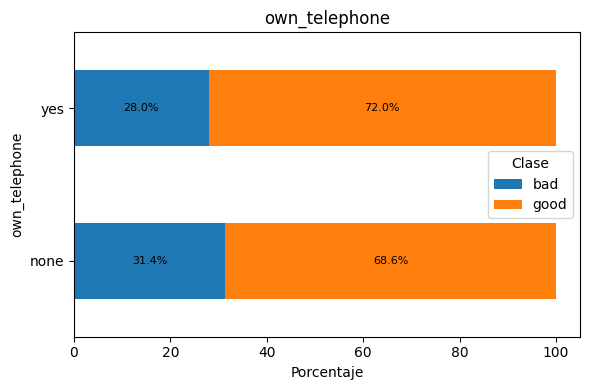

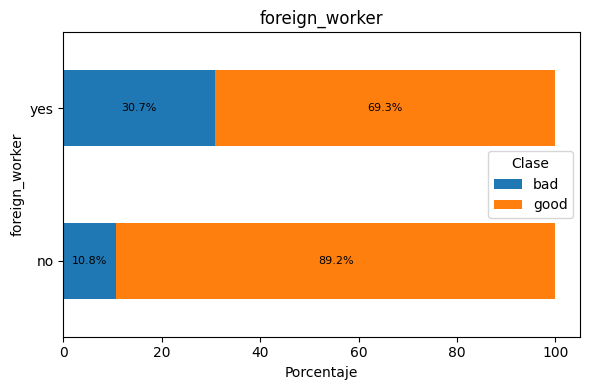

In [ ]:
for col in columnas_categoricas:

    tabla = pd.crosstab(
        df[col],
        df["class"],
        normalize="index"
    ) * 100

    ax = tabla.plot(
        kind="barh",
        stacked=True,
        figsize=(6,4) 
    )

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.1f%%",
            label_type="center",
            fontsize=8,
            color="black"
        )

    plt.title(col)
    plt.xlabel("Porcentaje")
    plt.ylabel(col)
    plt.legend(title="Clase")
    plt.tight_layout()
    plt.show()

Teniendo en cuenta el porcentaje de nuestros datos pertenecientes a cada clase (70% para la clase 'good' y el 30% para la clase 'bad'), podemos notar que hay ciertas variables cuyo porcentaje correspondiente a los créditos malos supera esta tasa base del 30%. Esto nos indica que son variables a las cuales debemos prestar mayor atención a la hora de evaluar un crédito, y que probablemente tengan un peso importante en nuestro modelo. Algunas de las más relevantes son:

- "checking status": Cuando la categoría es "<0", la proporción de créditos malos sube significativamente al 49.3%.
- "credit history": Cuando la categoría es "all paid" (57.1%) o "no credits/all paid" (62.5%), se observa una fuerte presencia de créditos malos.
- "purpose": Cuando la categoría es "education" (44%) o "others" (41.7%), suele haber una mayor tasa de incumplimiento.

Sin embargo, dado que el tamaño del dataset es moderadamente pequeño, existen casos donde estas tendencias reflejan únicamente el comportamiento de unas pocas observaciones. Por lo tanto, estos hallazgos no deben interpretarse como patrones predictivos absolutos, evitando así generalizaciones sesgadas por la baja representatividad muestral. Un ejemplo concreto ocurre en la variable 'purpose', donde la categoría 'other' cuenta con apenas 12 observaciones, lo que demuestra que su alto porcentaje de riesgo no es estadísticamente representativo.

Dejando de lado estos casos específicos, la distribución de la mayoría de las categorías se mantiene muy cercana al balance general de las clases (70% 'good' y 30% 'bad'). Por lo tanto, a nivel individual, la mayoría de las variables no ofrecen un indicador definitivo o absoluto por sí solas para determinar si un crédito será bueno o malo.

In [37]:
# Demostración del ejemplo mencionado respecto a la baja representatividad muestral

df['purpose'].value_counts()

purpose
radio/tv               280
new car                234
furniture/equipment    181
used car               103
business                97
education               50
repairs                 22
domestic appliance      12
other                   12
retraining               9
Name: count, dtype: int64

In [46]:
df['class'].value_counts(normalize=True)*100


class
b'good'    70.0
b'bad'     30.0
Name: proportion, dtype: float64